# Introduction:
Customer churn is a critical challenge for telecommunications companies, as acquiring new customers is typically more expensive than retaining existing ones. Predicting which customers are likely to leave allows companies to proactively intervene through targeted retention strategies such as service improvements, pricing adjustments, or personalized offers.

This project aims to develop a machine learning model to predict customer churn using historical customer data from a telecommunications provider. The dataset includes customer demographics, service subscriptions, contract details, billing information, and other behavioral indicators that may influence churn.

The analysis follows an end-to-end machine learning workflow, including data exploration, data cleaning, feature engineering, model development, evaluation, and interpretation of results. Multiple classification models are trained and compared to identify the approach that best predicts churn while balancing interpretability and predictive performance.

The final outcome of the project is a predictive model capable of identifying customers at risk of churn, along with insights into the key factors driving customer attrition. These insights can support data-driven decision making and help organizations design more effective customer retention strategies.

# a. Data Exploration

## i. Importing libraries & data

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Loading the Telco churn dataset
df = pd.read_excel("/content/Telco_customer_churn.xlsx")

# Inspecting the dataset
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## ii. Inspecting the dataset

In [ ]:
# Checking dataset dimensions
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

# Inspect data types and missing values
print("\nData types:\n")
print(df.dtypes)
print("\nMissing values:\n")
print(df.isnull().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())

# Summary statistics for numeric variables
df.describe()

Shape: (7043, 33)

Columns:
 ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

Data types:

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
In

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


> Initial inspection shows that the dataset has 7,043 rows and 33 columns, the available variables, their data types, and whether there are missing or duplicate records that need cleaning.

## iii. Exploring the target variable

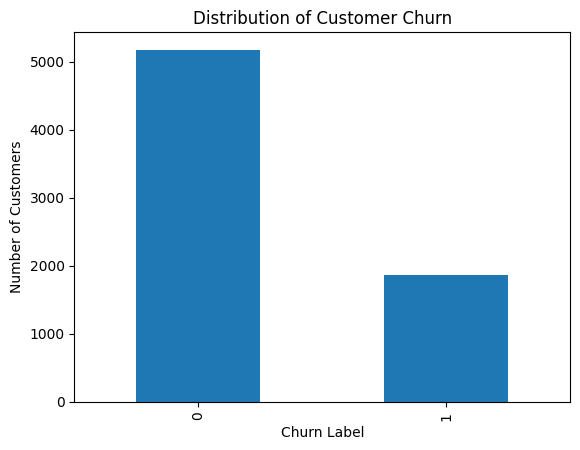

In [ ]:
# Examine churn distribution
df["Churn Label"].value_counts()

# Convert churn from Yes/No to binary if necessary
df["Churn Label"] = df["Churn Label"].map({"Yes":1, "No":0})

# Visualize churn imbalance
df["Churn Label"].value_counts().plot(kind="bar")
plt.title("Distribution of Customer Churn")
plt.ylabel("Number of Customers")
plt.show()

> The target distribution shows that most customers remain with the company, while a smaller proportion churn. This confirms that churn prediction is a moderately imbalanced classification problem since non-churn customers form the majority group, meaning model evaluation should pay attention to recall and ROC-AUC rather than accuracy alone.

# b. Data Cleaning

## i. Duplicates

In [ ]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

> Duplicate rows were checked to ensure repeated records do not bias the analysis or inflate model performance. None were detected

## ii. Nulls

In [ ]:
# Count missing values
missing = df.isnull().sum().sort_values(ascending=False)

missing

,0
Churn Reason,5174
CustomerID,0
Count,0
State,0
Country,0
Zip Code,0
Lat Long,0
Latitude,0
City,0
Gender,0


> Missing values were reviewed to identify incomplete variables and determine where data cleaning would be required. None were found.

In [ ]:
# Percentage of missing values by column
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

,0
Churn Reason,73.463013


> Missing-value percentages show the relative extent of incompleteness across columns, helping prioritize which variables require treatment or careful interpretation.

In [ ]:
# Fill categorical nulls with a placeholder category
cat_cols = df.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    # Convert to string to ensure 'Unknown' can be inserted without category issues
    df[col] = df[col].astype(str).replace('nan', 'Unknown')

# Convert Total Charges to numeric and impute missing numeric values
# Use "Total Charges" with a space, as confirmed in df.columns
if "Total Charges" in df.columns:
    df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# Impute missing numeric values using the median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

> Missing values were concentrated in a few columns, especially those related to churn explanation and billing, and were handled according to variable type and business meaning.
> Categorical nulls were assigned a placeholder label, while numeric nulls were imputed using the median to reduce distortion from extreme values.

In [ ]:
cat_cols = df.select_dtypes(include=["object","category"]).columns

df[cat_cols] = df[cat_cols].fillna("Unknown")

> Missing categorical values were replaced with a placeholder category so that incomplete records could still be retained during analysis and modelling.

## iii. Data types

In [ ]:
# Confirming data types
df.dtypes

,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


## iv. Dropping 'unneccesary' columns

In [ ]:
# Drop identifier columns that do not help prediction
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

> Customer identifiers were removed because they do not provide behavioural signal for churn prediction and may add unnecessary noise.

In [ ]:
# Convert numeric columns stored as text into proper numeric format
for col in df.columns:
    if df[col].dtype == "object":
        # Specifically handle 'Total Charges' to coerce errors, as it's a known problematic column
        if col == 'Total Charges':
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            try:
                df[col] = pd.to_numeric(df[col])
            except:
                pass


> Object columns were tested for numeric conversion so that values stored as text, such as charges, could be analysed correctly and included in the numeric preprocessing pipeline. Numeric missing values created during type conversion were imputed using the median to preserve the distribution while limiting the effect of extreme values.

# c. Exploratory Data Analysis

## i. Univariate EDA

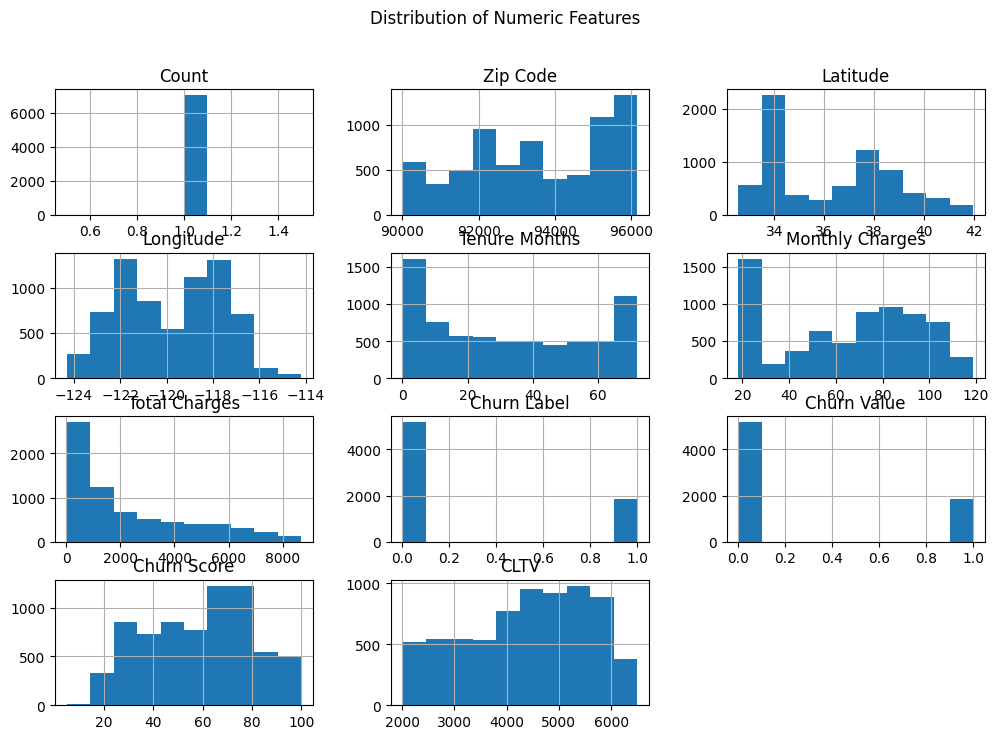

In [ ]:
# Check distribution of numerical features
df.hist(figsize=(12,8))
plt.suptitle("Distribution of Numeric Features")
plt.show()

> The numeric distributions show the spread, skewness, and possible outliers across quantitative variables, which helps identify preprocessing needs and potential business patterns.

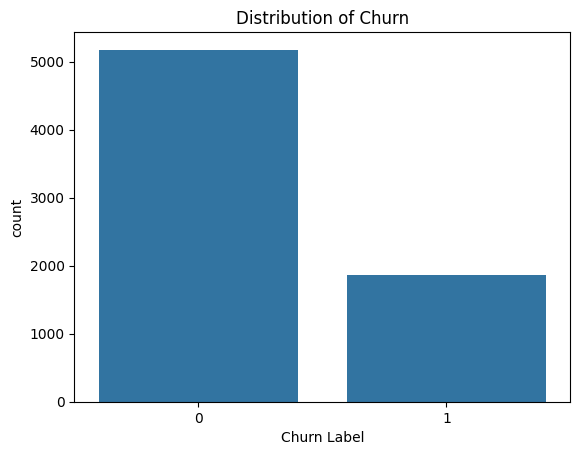

In [ ]:
# Distribution of tenure
sns.countplot(x="Churn Label", data=df)
plt.title("Distribution of Churn")
plt.show()

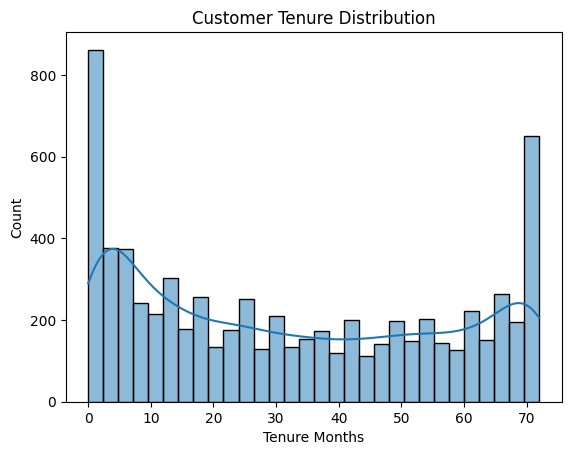

In [ ]:
# Distribution of tenure
sns.histplot(df["Tenure Months"], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.show()

> Customer tenure is concentrated more heavily among shorter durations, suggesting many customers are still relatively early in their lifecycle with the company.

In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

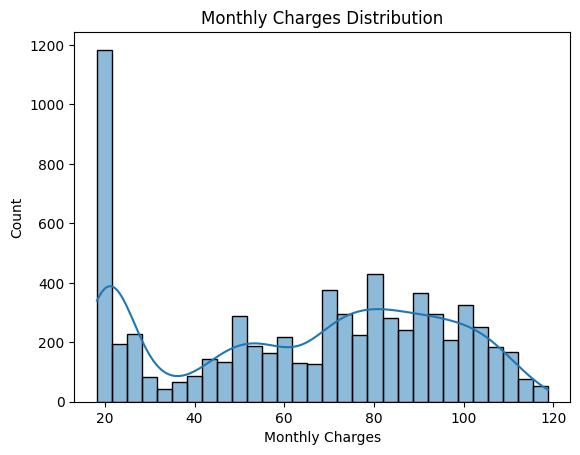

In [ ]:
# Distribution of monthly charges
sns.histplot(df["Monthly Charges"], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

> Monthly charges vary across a wide range, indicating that customers fall into distinct spending levels that may relate to service mix and churn risk.

## ii. Bivariate EDA

In [ ]:
# Compare tenure  against churn
df["tenure_group"] = pd.cut(
    df["Tenure Months"],
    bins=[0,12,24,48,72],
    labels=["0-1yr","1-2yr","2-4yr","4+yr"]
)

pd.crosstab(df["tenure_group"], df["Churn Label"], normalize="index") * 100

Churn Label,0,1
tenure_group,,
0-1yr,52.321839,47.678161
1-2yr,71.289062,28.710938
2-4yr,79.611041,20.388959
4+yr,90.486824,9.513176


> Churn is highest among shorter-tenure customers, while longer-tenure customers are more likely to stay. This suggests retention strengthens as customer relationships mature.

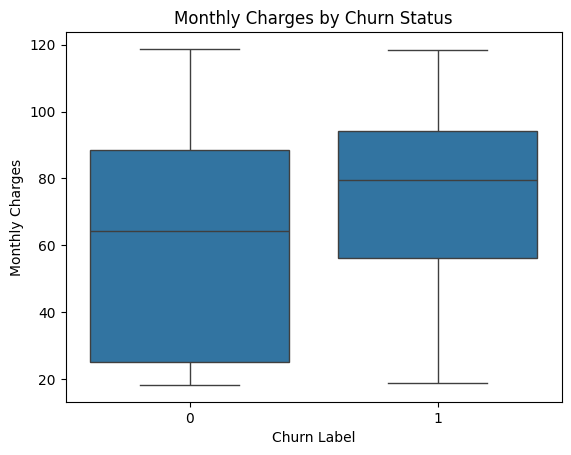

In [ ]:
# Monthly charges vs churn
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)

plt.title("Monthly Charges by Churn Status")
plt.show()

> Customers who churn show somewhat different monthly charge patterns from those who stay, suggesting that pricing or perceived value may influence attrition.

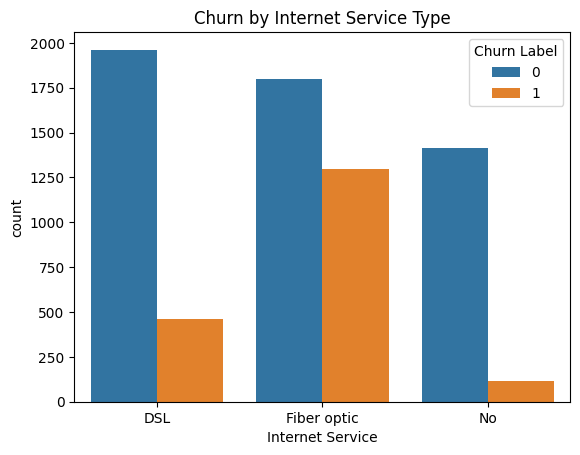

In [ ]:
# Distribution of internet service against churn
sns.countplot(x="Internet Service", hue="Churn Label", data=df)

plt.title("Churn by Internet Service Type")
plt.show()

> Churn differs across internet service categories, indicating that service type may be associated with different levels of satisfaction, value, or retention risk.

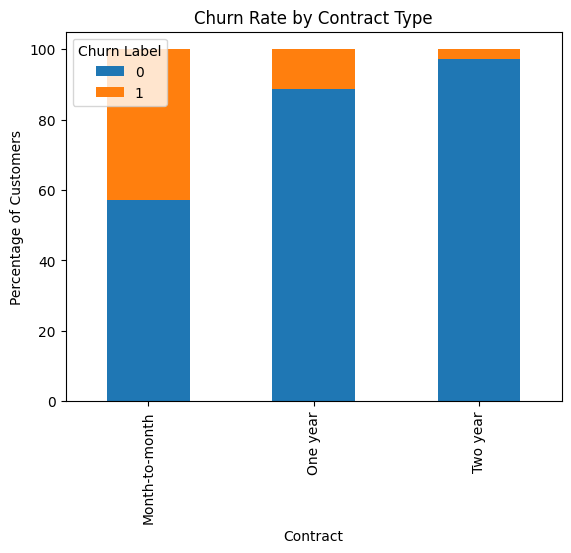

In [ ]:
# Compare churn rates across contract types
contract_churn = pd.crosstab(df["Contract"], df["Churn Label"], normalize="index") * 100

contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage of Customers")
plt.show()

> Customers on month-to-month contracts show markedly higher churn than those on longer-term contracts, making contract type one of the clearest drivers of churn in the dataset.

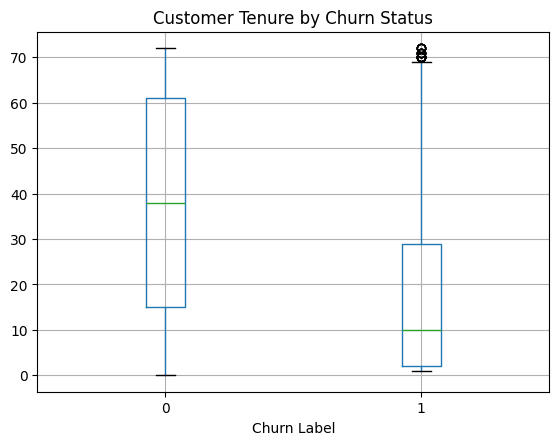

In [ ]:
# Customers with shorter tenure often churn more frequently
df.boxplot(column="Tenure Months", by="Churn Label")
plt.title("Customer Tenure by Churn Status")
plt.suptitle("")
plt.show()

> The tenure boxplot confirms that churned customers generally have shorter customer lifespans than retained customers, reinforcing tenure as an important churn indicator.

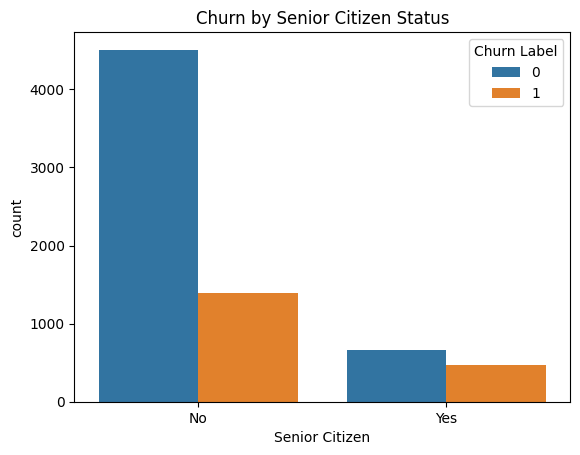

In [ ]:
# Demographics
sns.countplot(x="Senior Citizen", hue="Churn Label", data=df)
plt.title("Churn by Senior Citizen Status")
plt.show()

> Churn differs across demographic groups, indicating that customer profile may also influence retention risk.

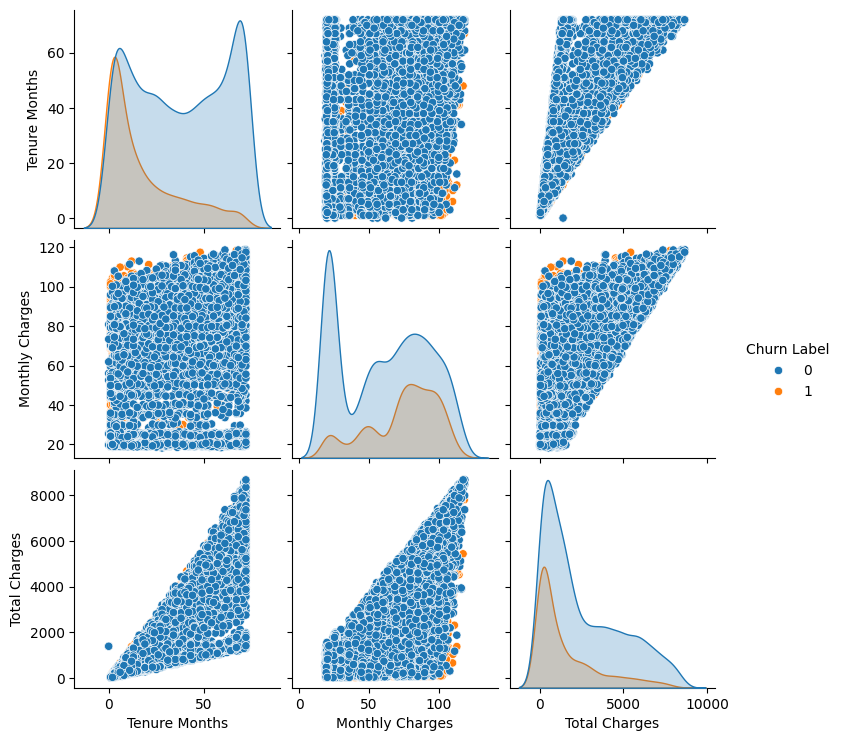

In [ ]:
# Pairplot for numerical features
sns.pairplot(
    df[["Tenure Months","Monthly Charges","Total Charges","Churn Label"]],
    hue="Churn Label"
)

> The pairwise feature plots show separation patterns between churned and retained customers, with tenure and billing-related variables appearing particularly informative.

## iii. Correlation Analysis

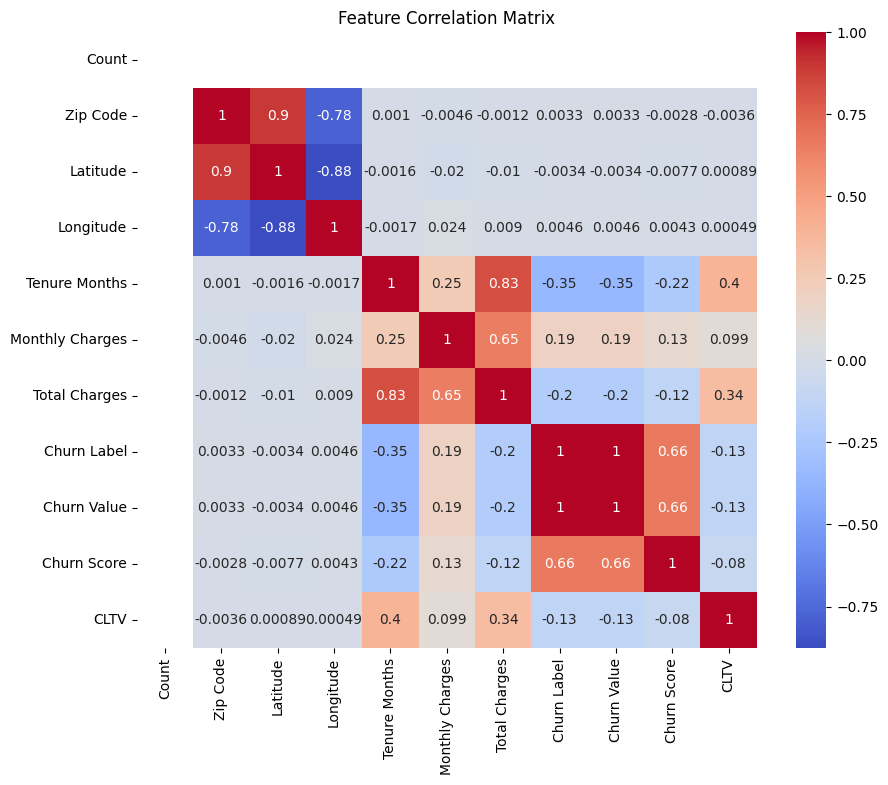

In [ ]:
# Correlation analysis
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

> The correlation matrix shows that total charges are strongly related to tenure and monthly charges, which is expected because total charges accumulate over time.

# d. Feature Engineering

In [ ]:
# Create tenure groups to improve interpretability
df["tenure_group"] = pd.cut(
    df["Tenure Months"],
    bins=[0,12,24,48,72],
    labels=["0-12","13-24","25-48","49-72"],
    include_lowest=True
)

> Tenure was grouped into lifecycle stages to capture nonlinear retention patterns and make churn differences across customer age bands easier to interpret.

In [ ]:
# Segment customers based on spending levels
df["MonthlyCharges_band"] = pd.qcut(
    df["Monthly Charges"],
    q=4,
    labels=["Low","Mid-Low","Mid-High","High"],
    duplicates="drop"
)

> Monthly charges were segmented into spending tiers to capture billing patterns that may not be fully reflected by the raw numeric values alone.

# e. Modeling


In [ ]:
# Separate predictors and target
X = df.drop(columns=["Churn Label"]).copy()
y = df["Churn Label"].copy()

> The predictors and target variable were separated to prepare the dataset for supervised machine learning.

## Handling data leakage

In [ ]:
# drop columns with any details on churn so the model does not cheat
# Check for churn-related columns that may leak the target
for col in df.columns:
    if "churn" in col.lower() and col != "Churn Label":
        print(col)

Churn Value
Churn Score
Churn Reason


In [ ]:
# Remove columns that directly leak churn information
leakage_cols = [
    "CustomerID",
    "Churn Value",
    "Churn Score",
    "Churn Reason",
    "CLTV"
]

X = X.drop(columns=[col for col in leakage_cols if col in X.columns])

> Churn-related fields were reviewed to identify variables that directly reveal the target or depend on the churn outcome, which would otherwise lead to data leakage. These columns that directly reveal churn status or are derived from churn outcomes were removed so that model performance would reflect realistic predictive ability.

In [ ]:
# Confirming that target variable isn't in X
print("Target in X?", "Churn Label" in X.columns)
print("Leakage columns still in X:", [col for col in leakage_cols if col in X.columns])

Target in X? False
Leakage columns still in X: []


In [ ]:
# Removing geographical noise
geo_cols = [
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]

X = X.drop(columns=geo_cols)

In [ ]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Force categorical columns to string type for consistent encoding
for col in categorical_features:
    # Convert to string type first (this turns np.nan into 'nan' string)
    X[col] = X[col].astype(str)
    # Then replace the 'nan' string with 'Missing'
    X[col] = X[col].replace('nan', 'Missing')

> Features were divided into numeric and categorical groups so each type could be preprocessed in an appropriate way.

In [ ]:
# Numeric preprocessing
# Imputing missing values and scale features
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
# Imputing and encode categories
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

> Separate preprocessing pipelines were created for numeric and categorical variables, then combined into a single transformation workflow for consistent model input preparation.

In [ ]:
# Split dataset while preserving churn distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## i. Logistic Regression (Baseline Model)
Logistic Regression was implemented as the baseline model because it provides a simple interpretable benchmark for classification performance.

In [ ]:
#Logistic regression
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Count', 'Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['...
                                                   'Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method',
                                                   'tenure_group',
                                                   'MonthlyCharges_band'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

> Logistic Regression was used as a simple and interpretable baseline model as it establishes a baseline level of predictive performance for churn classification.

## ii. Random Forest (Ensemble Model)
Random Forest was used as it's a method that captures nonlinear relationships and interactions between customer attributes.

In [ ]:
# Randoom forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Count', 'Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['...
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method',
                                                   'tenure_group',
                                                   'MonthlyCharges_band'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

> Random Forest was trained as a nonlinear ensemble model capable of capturing more complex interactions among customer characteristics.

## iii. Gradient Boosting
Gradient Boosting sequentially improves prediction accuracy by correcting errors from previous trees.

In [ ]:
# Gradient Boosting  model
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# Train model
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

> This was added as a boosting-based baseline to test whether sequential ensemble learning improves churn prediction performance.

## iv. Multi-layer Perceptron
A Multi-Layer Perceptron neural network was trained to capture complex nonlinear relationships between customer attributes and churn behaviour.

In [ ]:
# Initialize neural network
mlp_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64,32),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ))
])

# Train model
mlp_model.fit(X_train, y_train)

# Predictions
mlp_preds = mlp_model.predict(X_test)
mlp_probs = mlp_model.predict_proba(X_test)[:,1]

# Evaluation
print("Neural Network Classification Report")
print(classification_report(y_test, mlp_preds))

print("Neural Network ROC AUC:", roc_auc_score(y_test, mlp_probs))

Neural Network Classification Report
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      1035
           1       0.51      0.46      0.49       374

    accuracy                           0.74      1409
   macro avg       0.66      0.65      0.66      1409
weighted avg       0.73      0.74      0.74      1409

Neural Network ROC AUC: 0.7570694153814359


# f. Model Evaluation
Model performance was evaluated using classification metrics and ROC-AUC to assess how well each model distinguishes between churned and retained customers.

In [ ]:
# Generate predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]

# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.794180269694819
Precision: 0.6428571428571429
Recall: 0.5053475935828877
F1: 0.5658682634730539
ROC AUC: 0.8433516753209848


In [ ]:
# Model Comparison Table
results = []

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "MLP": mlp_model
}

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.748758,0.518248,0.759358,0.616052,0.837854
1,Random Forest,0.794180,0.642857,0.505348,0.565868,0.843352
2,Gradient Boosting,0.808375,0.673333,0.540107,0.599407,0.849937
3,MLP,0.741661,0.514970,0.459893,0.485876,0.757069


> Comparing all baseline models side by side makes it easier to identify which algorithm provides the best balance of discrimination, precision, and recall.

In [ ]:
# Sorting
results_df.sort_values("ROC_AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Gradient Boosting,0.808375,0.673333,0.540107,0.599407,0.849937
1,Random Forest,0.794180,0.642857,0.505348,0.565868,0.843352
0,Logistic Regression,0.748758,0.518248,0.759358,0.616052,0.837854
3,MLP,0.741661,0.514970,0.459893,0.485876,0.757069


> In churn prediction, recall is particularly important, since failing to identify a customer who will churn may result in lost revenue opportunities.

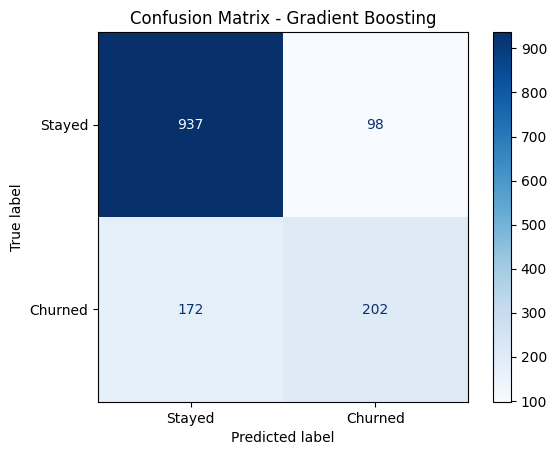

In [ ]:
# Using Gradient Boosting as the final selected model
final_model = gb_model

# Generate predictions on the test set
y_pred_gb = final_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

> The confusion matrix provides a more detailed view of model performance by separating correct predictions from classification errors. For churn management, a useful model should keep false negatives reasonably low while maintaining good precision. The Gradient Boosting model achieves a practical balance by improving churn detection without generating as many false alarms as Logistic Regression.

In [ ]:
X.columns

Index(['Count', 'Country', 'State', 'City', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'tenure_group',
       'MonthlyCharges_band'],
      dtype='object')

<Figure size 800x600 with 0 Axes>

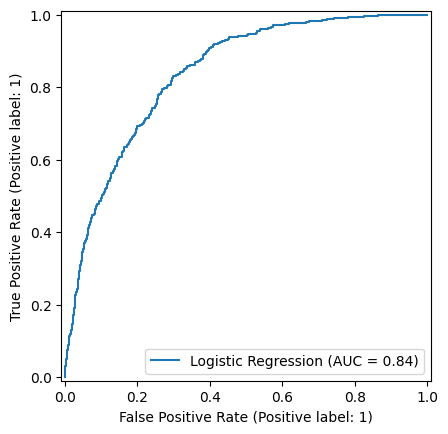

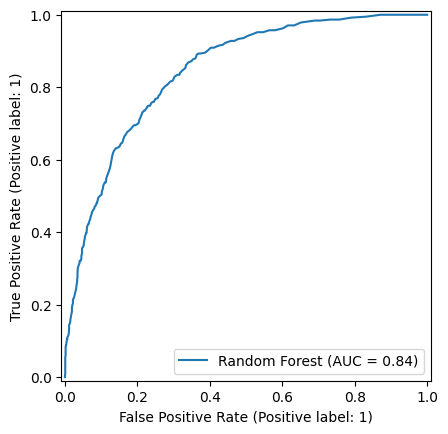

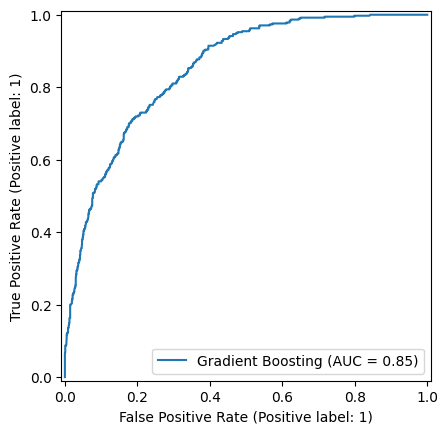

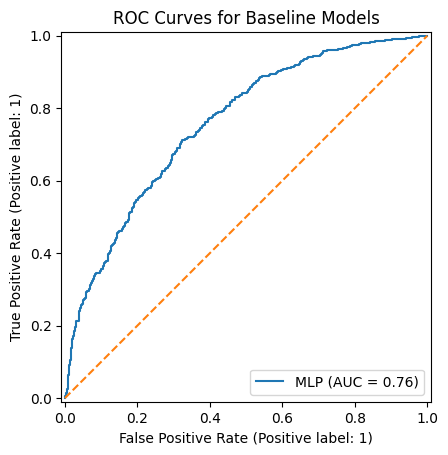

In [ ]:
# Plot ROC curves for all baseline models
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob_model = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob_model, name=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves for Baseline Models")
plt.show()

> The results show that Gradient Boosting achieved the strongest overall performance, with the highest Accuracy (0.808) and the highest ROC-AUC (0.850). This indicates that it was the most effective model at distinguishing churners from retained customers while also maintaining a good balance between precision and recall.
>
> Random Forest performed similarly well, with a ROC-AUC of 0.843, confirming that ensemble tree-based models are well suited to this churn dataset. However, its slightly lower Accuracy, Precision, Recall, and ROC-AUC show that it was marginally less effective than Gradient Boosting.
>
> Logistic Regression produced the highest Recall (0.759), meaning it identified the largest proportion of actual churners. This is useful in churn prediction because missing a true churner can result in lost revenue opportunities. However, its lower Precision (0.518) shows that this came at the cost of more false alarms, meaning more customers would be flagged as churn risks even when they were likely to stay.
>
> The MLP neural network recorded the weakest performance across most metrics, especially Recall (0.460), F1-score (0.486), and ROC-AUC (0.757). This suggests that the neural network was less effective at learning churn patterns from this structured tabular dataset than the ensemble tree models. This is consistent with many applied machine learning cases where boosted trees outperform neural networks on business tabular data.
>
> Overall, the evaluation suggests that Gradient Boosting offers the best balance between business usefulness and predictive strength. It identifies churners more accurately than the other models without over-prioritizing recall at the expense of too many false positives.

In [ ]:
# Hyperparameter tuning for Gradient Boosting
gb_param_grid = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__learning_rate": [0.05, 0.1, 0.2],
    "classifier__max_depth": [2, 3, 4],
    "classifier__subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

best_gb_model = gb_grid.best_estimator_

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)
print("\nBest Cross-Validated ROC-AUC:")
print(gb_grid.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Gradient Boosting Parameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}

Best Cross-Validated ROC-AUC:
0.863345077281733


> Gradient Boosting was tuned using grid search to identify the parameter combination that maximized ROC-AUC. The tuning process explored the number of boosting stages, learning rate, tree depth, and subsampling ratio. These parameters directly affect the model’s complexity, learning behaviour, and generalization performance.

In [ ]:
# Hyperparameter tuning for Random Forest
rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 15],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

best_rf_model = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)
print("\nBest Cross-Validated ROC-AUC:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Random Forest Parameters:
{'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}

Best Cross-Validated ROC-AUC:
0.8582550992799506


> Random Forest was tuned using GridSearchCV to determine whether hyperparameter optimization could improve its predictive performance.
>
>The optimized Random Forest achieved a cross-validated ROC-AUC of 0.858, representing a modest improvement compared to the baseline configuration.
>
>This result indicates that adjusting tree depth and sampling parameters can enhance the model’s discrimination ability, although the improvement remains slightly below the performance observed for Gradient Boosting during cross-validation.

In [ ]:
# Cross-validation using ROC-AUC as the optimization metric
cv_results = []

candidate_models = {
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in candidate_models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Mean ROC-AUC": scores.mean(),
        "CV Std Dev": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV Mean ROC-AUC", ascending=False)
cv_results_df

,Model,CV Mean ROC-AUC,CV Std Dev
1,Gradient Boosting,0.859388,0.015669
0,Random Forest,0.845999,0.011696


> Five-fold cross-validation was performed to evaluate the generalization ability of the candidate ensemble models.
>
>Gradient Boosting achieved a mean ROC-AUC of 0.859, outperforming Random Forest, which achieved 0.846.
>
>The relatively small standard deviations (0.0157 for Gradient Boosting and 0.0117 for Random Forest) indicate that both models produced stable performance across folds, suggesting that the models generalize well and are not heavily dependent on a specific train-test split.
>
> Based on cross-validation performance, Gradient Boosting demonstrated the strongest predictive capability, and was therefore prioritized for further optimization.

In [ ]:
# Evaluating the optimized models
optimized_results = []

optimized_models = {
    "Optimized Random Forest": best_rf_model,
    "Optimized Gradient Boosting": best_gb_model
}

for name, model in optimized_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    optimized_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

optimized_results_df = pd.DataFrame(optimized_results).sort_values("ROC_AUC", ascending=False)
optimized_results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Optimized Gradient Boosting,0.806246,0.666667,0.540107,0.596750,0.856425
0,Optimized Random Forest,0.772179,0.551859,0.754011,0.637288,0.852183


> After hyperparameter tuning, both ensemble models showed strong predictive performance.
>
>Optimized Gradient Boosting achieved the highest ROC-AUC (0.856), confirming its superior ability to distinguish between churners and retained customers.
>
>While Optimized Random Forest produced a higher Recall (0.754), indicating stronger detection of churners, it also produced lower Precision and overall Accuracy. This suggests that Random Forest generated more false positive predictions.
>
>In contrast, Gradient Boosting maintained higher Precision and Accuracy, providing a better balance between correctly identifying churners and avoiding unnecessary churn alerts.

In [ ]:
# Compare models before and after optimization
baseline_best = results_df[results_df["Model"].isin(["Random Forest", "Gradient Boosting"])].copy()
baseline_best["Stage"] = "Baseline"

optimized_compare = optimized_results_df.copy()
optimized_compare["Stage"] = "Optimized"

comparison_df = pd.concat([baseline_best, optimized_compare], ignore_index=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Stage
0,Random Forest,0.794180,0.642857,0.505348,0.565868,0.843352,Baseline
1,Gradient Boosting,0.808375,0.673333,0.540107,0.599407,0.849937,Baseline
2,Optimized Gradient Boosting,0.806246,0.666667,0.540107,0.596750,0.856425,Optimized
3,Optimized Random Forest,0.772179,0.551859,0.754011,0.637288,0.852183,Optimized


> The comparison between baseline and optimized models shows that hyperparameter tuning improved predictive performance.
>
> The baseline Gradient Boosting model achieved an ROC-AUC of 0.850, which increased to 0.856 after optimization, indicating improved ability to rank customers by churn risk. Random Forest also improved slightly from 0.843 to 0.852 ROC-AUC, but remained below the optimized Gradient Boosting model.
>
> Based on cross-validation, hyperparameter tuning, and test-set evaluation, Gradient Boosting was selected as the final model.
>
> The optimized model achieved ROC-AUC 0.856, Accuracy 0.806, Precision 0.667, and Recall 0.540, providing strong discrimination between churners and retained customers while maintaining a balanced trade-off between churn detection and false positives.
>
> Because churn prediction is primarily a risk ranking problem, ROC-AUC was used as the primary optimization metric. Although accuracy decreased slightly after tuning, the higher ROC-AUC indicates improved prioritization of high-risk customers.

In [ ]:
# Select final optimized model (Gradient Boosting)
best_model = best_gb_model

# Persist trained model for deployment
joblib.dump(best_model, "final_churn_model.pkl")
joblib.dump(X.columns.tolist(), "model_features.pkl")

['model_features.pkl']

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


Link to S